In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.7 MB/s eta 0:00:00


In [2]:
# Import libraries
import os
import cv2
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
# Dataset paths

train_path = '/content/drive/MyDrive/Vehicle_count/train/images'
valid_path = '/content/drive/MyDrive/Vehicle_count/valid/images'
test_path = '/content/drive/MyDrive/Vehicle_count/test/images'

In [4]:
# Number of images

print("Train Images:", len(os.listdir(train_path)))
print("Valid Images:", len(os.listdir(valid_path)))
print("Test Images:", len(os.listdir(test_path)))

Train Images: 800
Valid Images: 100
Test Images: 100


In [5]:
# Read sample image

sample_image = os.listdir(train_path)[0]

img = cv2.imread(os.path.join(train_path, sample_image))

print("Image Shape:", img.shape)

Image Shape: (640, 640, 3)


In [6]:
# Resize image

resized_img = cv2.resize(img, (640, 640))

print("Resized Shape:", resized_img.shape)

Resized Shape: (640, 640, 3)


In [7]:
# Normalize image

normalized_img = resized_img / 255.0

print("Normalization Done")

Normalization Done


In [10]:

model = YOLO('yolov8n.pt')

In [11]:
# Train model

model.train(
    data='/content/drive/MyDrive/Vehicle_count/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16
)

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Vehicle_count/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tr

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7dc60db01460>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [12]:
# Validation

model.val()

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.3 ms, read: 23.4±9.5 MB/s, size: 82.4 KB)
val: Scanning /content/drive/MyDrive/Vehicle_count/valid/labels.cache... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 22.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.3it/s 5.2s
                   all        100       1107      0.909      0.887      0.937      0.753
                   bus         35         37          1      0.889       0.97      0.903
                   car         92        366      0.944      0.932      0.971      0.782
             motorbike         90        611      0.835      0.772      0.859      0.523
                 truck         62         93      0.856      0.957      0.948      0.806
Speed: 5.9ms preprocess, 8.9ms infe

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7dc60c146ff0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [20]:
print("mAP50 Accuracy:", metrics.box.map50)
print("mAP50-95 Accuracy:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

mAP50 Accuracy: 0.9371478066313684
mAP50-95 Accuracy: 0.753401471200554
Precision: 0.9088522959751659
Recall: 0.8873395564884479


In [13]:
# Testing

model.predict(
    source='/content/drive/MyDrive/Vehicle_count/test/images',
    save=True
)


image 1/100 /content/drive/MyDrive/Vehicle_count/test/images/image_1_1006_jpg.rf.65087e32ceb6d70e6f7dc81077c63093.jpg: 640x640 5 cars, 10 motorbikes, 19.3ms
image 2/100 /content/drive/MyDrive/Vehicle_count/test/images/image_1_127_jpg.rf.e378c858eb0d4dc5f609bdf70f4dff9d.jpg: 640x640 4 cars, 19 motorbikes, 33.5ms
image 3/100 /content/drive/MyDrive/Vehicle_count/test/images/image_1_1281_jpg.rf.90f0eb6c0e54904035864e8eca93f267.jpg: 640x640 1 bus, 1 motorbike, 7.6ms
image 4/100 /content/drive/MyDrive/Vehicle_count/test/images/image_1_1449_jpg.rf.cef2ca56f852e86e8a0487c11c01bcc7.jpg: 640x640 1 bus, 2 cars, 12 motorbikes, 1 truck, 7.7ms
image 5/100 /content/drive/MyDrive/Vehicle_count/test/images/image_1_1751_jpg.rf.d33c55fa3cf0de702122d62225a1c7f4.jpg: 640x640 2 motorbikes, 1 truck, 7.8ms
image 6/100 /content/drive/MyDrive/Vehicle_count/test/images/image_1_1781_jpg.rf.b63d466732a3bd3030c22952741ccc92.jpg: 640x640 1 bus, 1 car, 16 motorbikes, 1 truck, 9.1ms
image 7/100 /content/drive/MyDrive

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'bus', 1: 'car', 2: 'motorbike', 3: 'truck'}
 obb: None
 orig_img: array([[[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        ...,
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
        

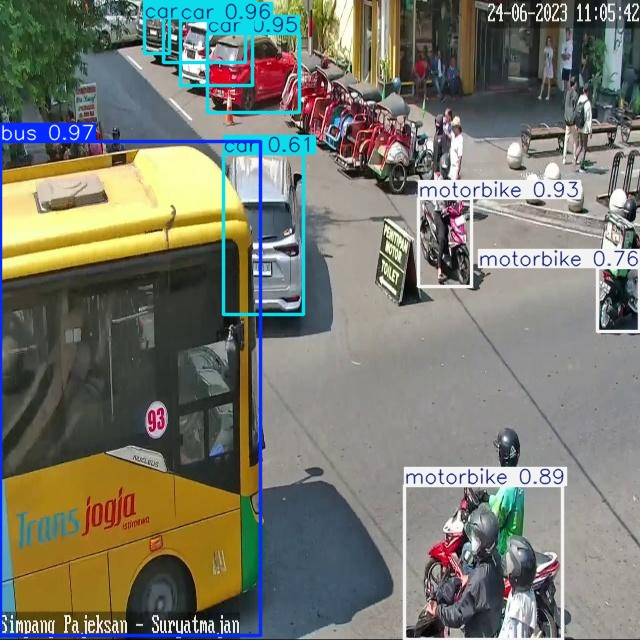

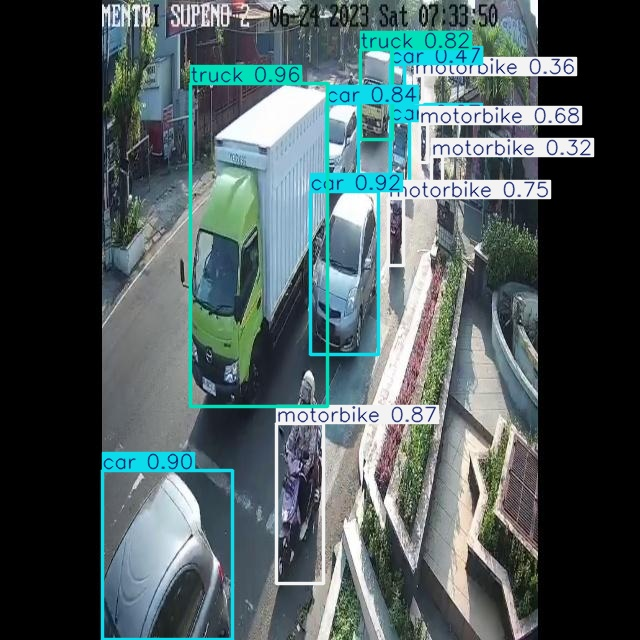

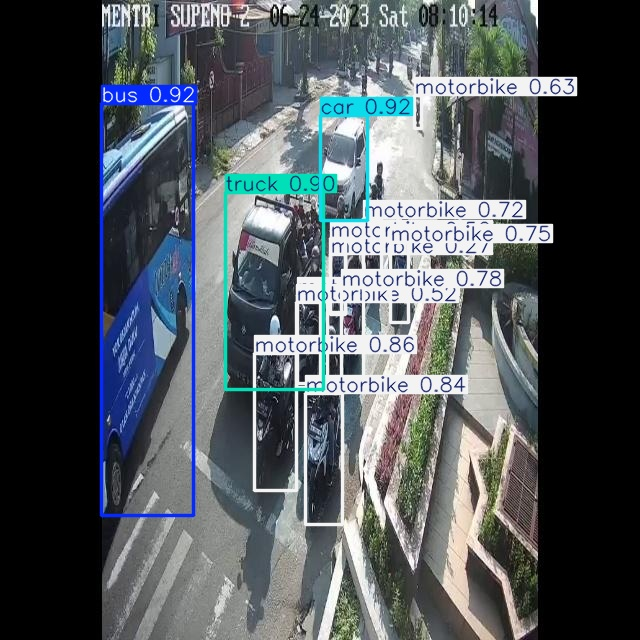

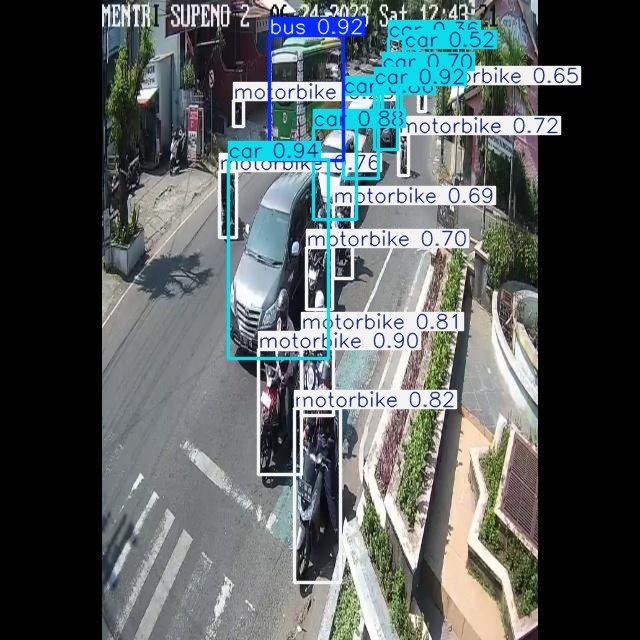

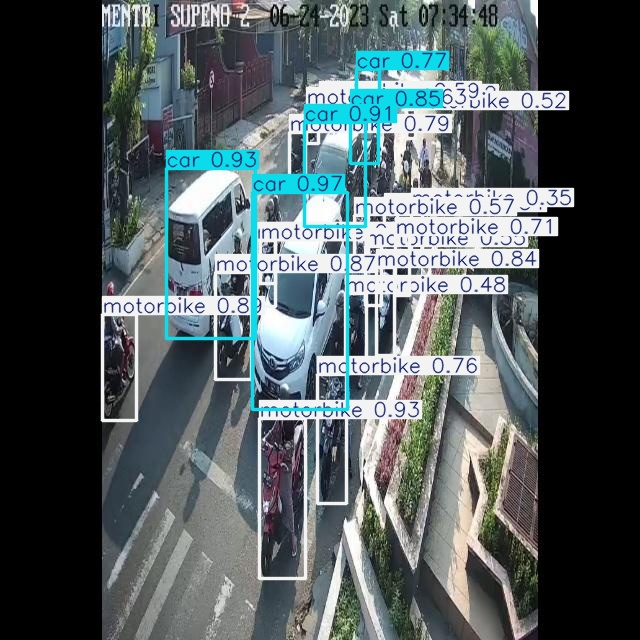

In [14]:
# Example
from IPython.display import Image, display
import os

result_path = '/content/runs/detect/predict'

for img in os.listdir(result_path)[:5]:
    display(Image(filename=os.path.join(result_path, img)))

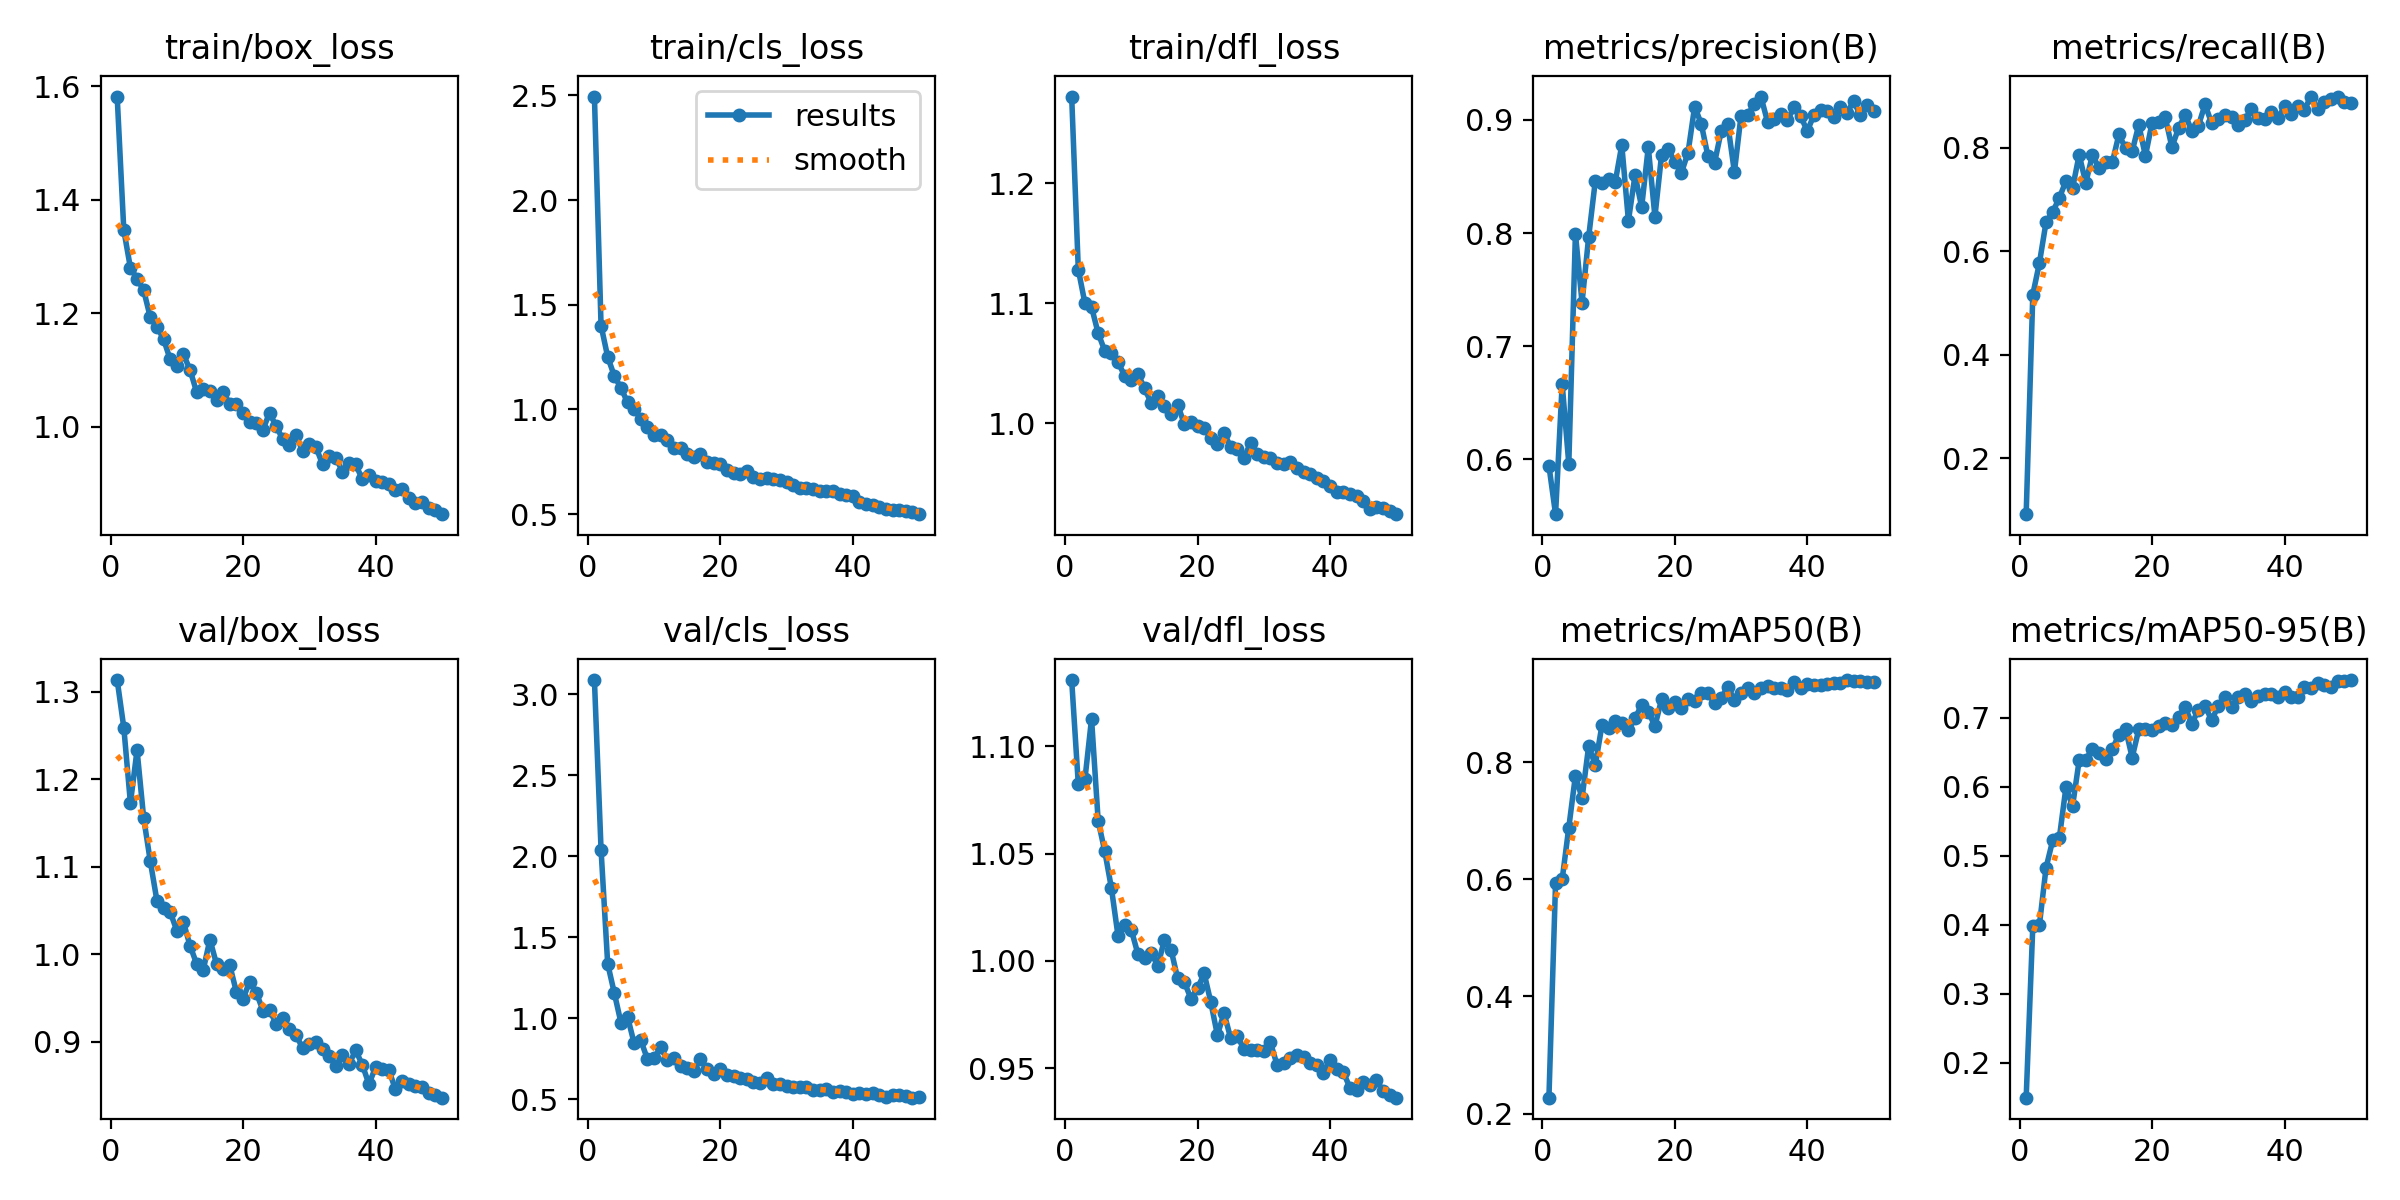

In [16]:
# Show training graph

from IPython.display import Image, display

display(Image('/content/runs/detect/train/results.png'))

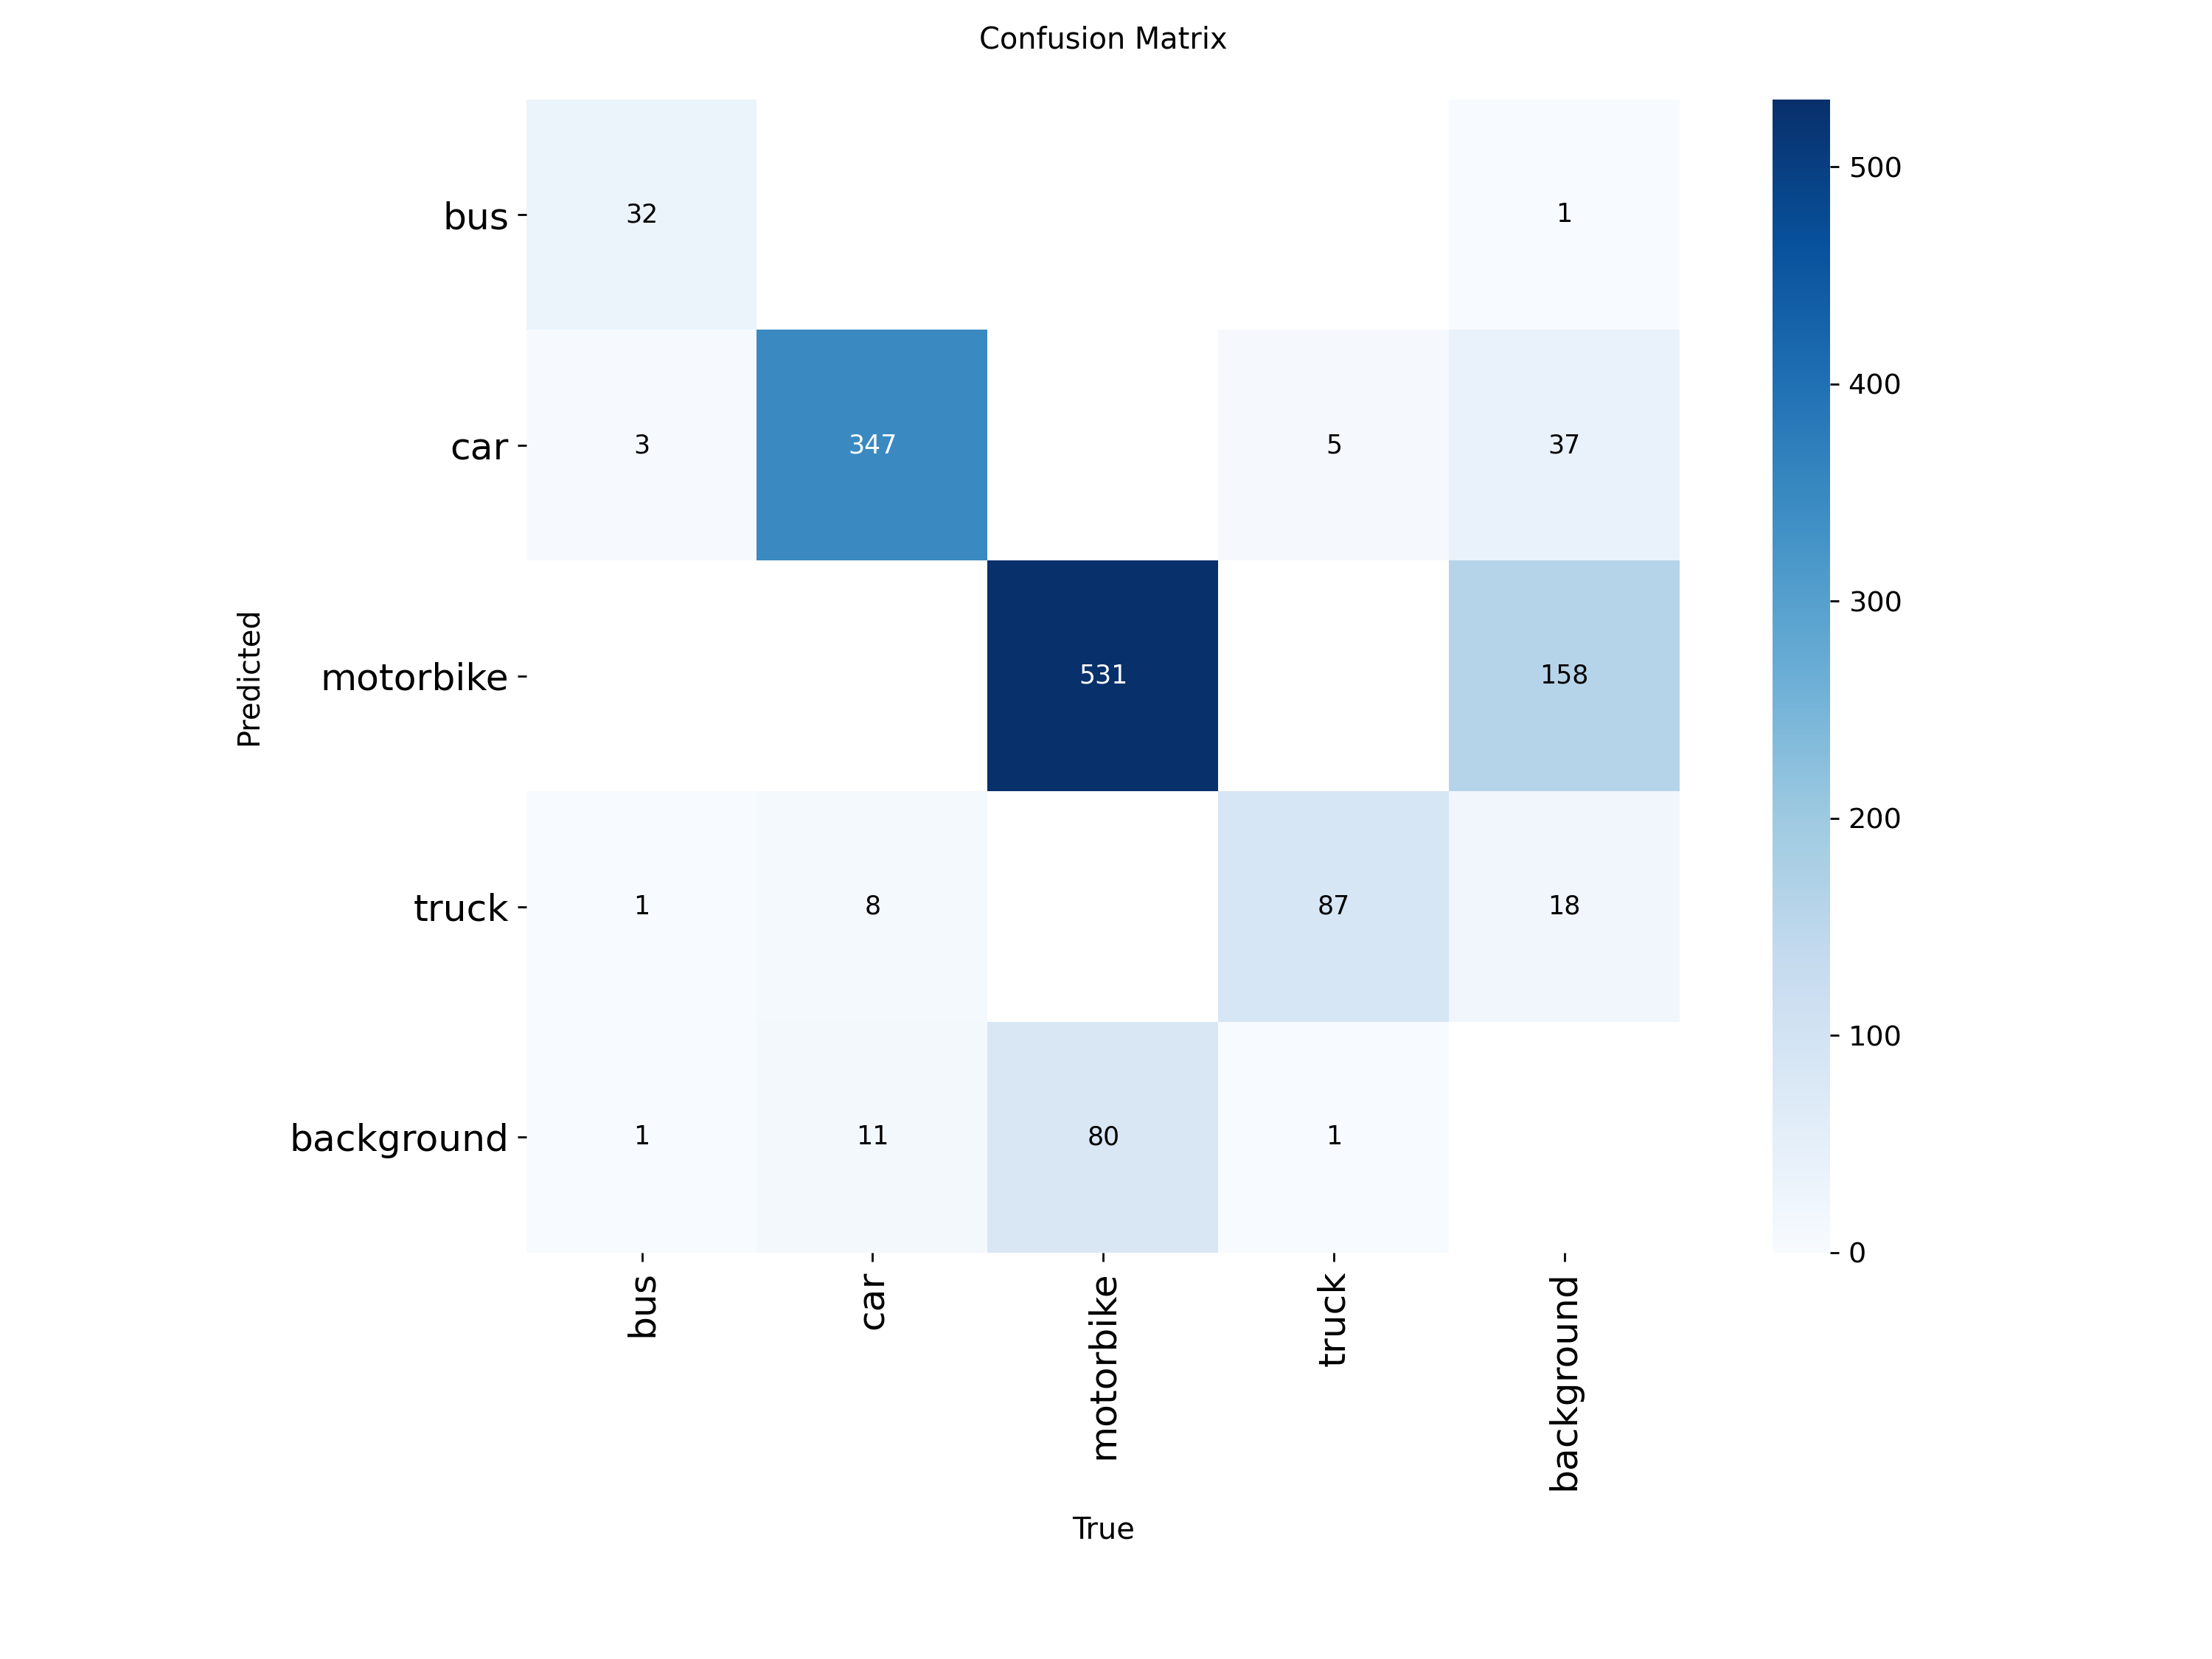

In [17]:
# Show confusion matrix

display(Image('/content/runs/detect/train/confusion_matrix.png'))